# 120 Years of Olympic History: Athletes and Results

## Problem Definition

The Olympic Games, held since 1896, provide one of the most comprehensive datasets
for analyzing global trends in sports, gender participation, and national performance.
Despite the long history of the Games, systematic analysis of gender dynamics,
national specializations, and contextual factors such as hosting effects remains
incomplete. Understanding these patterns is crucial not only for sports history but
also for broader discussions on gender equality, cultural influence, and national
strategies in sports.

This study aims to analyze Olympic data spanning from 1896 to 2016.

## Research Questions & Sub-Questions

This study is motivated by two central research axes:

1. **How has female participation in the Olympic Games evolved across time, sports, and countries?**
   - What percentage of athletes were female in each Olympic year?
   - Which sports introduced female categories earliest, and which were the last?
   - Which countries have sent the highest number of female athletes in Olympic history?

2. **How do countries perform in the Olympic Games in terms of overall success, specialization in sports, and the impact of hosting?**
    - Which countries have the highest total medal counts?
    - In which sports do the top medal-winning countries particularly excel?
    - Do host countries win more medals when hosting?

By addressing these research questions, the study aims to produce a holistic
understanding of the Olympic Games as both a sporting competition and a
socio-political phenomenon. The findings will contribute to discussions on gender
equality, the evolution of international sports systems, and the role of mega-events
in shaping national athletic success.

**Data Source**: [Kaggle - 120 years of Olympic history: athletes and results](https://www.kaggle.com/heesoo37/120-years-of-olympic-history-athletes-and-results)

## Scope

The analysis covers **both the Summer and the Winter Games**. The research questions
ask about the Olympic Games, so restricting the population to one season would answer
a narrower question than the one posed.

**Sub-question 2.3 reports the two seasons separately and compares them.** Winter
medals are concentrated in far fewer nations, so hosting cannot open the same breadth
of new events that it can in Summer. That makes the seasonal difference a hypothesis
worth testing rather than a duplicated chart. Everywhere else a season split would
produce a second table saying much the same thing.

All calculations live in `src/olympics/` and are covered by 92 tests. This notebook
imports them and contains no analysis logic of its own, so every number shown here is
produced by a function that is tested independently.

In [1]:
import sys

sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess

from olympics.loading import clean_events, load_events, load_noc, medal_rows
from olympics.medals import (
    assign_final_noc,
    medal_table,
    medals_by_country_and_sport,
    one_medal_per_event,
)
from olympics.participation import (
    first_female_year_by_sport,
    participation_by_year,
    top_countries_by_female_athletes,
)
from olympics.hosting import (
    compare_seasons,
    host_country_by_games,
    host_vs_baseline,
    medals_by_year_and_country,
)

plt.style.use("seaborn-v0_8")
plt.rcParams["figure.dpi"] = 110

## Loading and preparing the data

Two reductions happen here, and the second matters for reading every medal figure
that follows.

Duplicate rows are removed. Then team results are collapsed: the source has one row
per athlete per event, so a rowing eight winning gold produces eight gold rows.
Counting those directly inflates team sports and matches no official medal table.

In [2]:
events = load_events("../data/athlete_events.csv")
noc = load_noc("../data/noc_regions.csv")

games = clean_events(events, season=None)

medals = assign_final_noc(medal_rows(games), noc)
dedup = one_medal_per_event(medals)

print(f"{len(events):,} rows loaded")
print(f"{len(games):,} rows after removing duplicates")
print(f"{len(medal_rows(games)):,} of those recorded a medal")
print(f"{len(dedup):,} medal results after collapsing team entries")
print()
print(games.groupby("Season").size().to_string())

games.head()

271,116 rows loaded
269,731 rows after removing duplicates
39,772 of those recorded a medal
18,878 medal results after collapsing team entries

Season
Summer    221167
Winter     48564


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,<NA>
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,<NA>
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,<NA>
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,<NA>


# Research Question 1: How has female participation evolved across time, sports, and countries?

## Sub-question 1.1: What percentage of athletes were female in each Olympic year?

Counts are of **distinct athletes**, not of rows. An athlete entered in four events is
one participant, not four.

In [3]:
participation = participation_by_year(games)
participation.tail(10).round(1)

Sex,female,male,total,female_pct
Year,,,,
1998,789,1390,2179,36.2
2000,4068,6579,10647,38.2
2002,886,1513,2399,36.9
2004,4300,6257,10557,40.7
2006,955,1539,2494,38.3
2008,4609,6290,10899,42.3
2010,1033,1503,2536,40.7
2012,4654,5863,10517,44.3
2014,1102,1643,2745,40.1


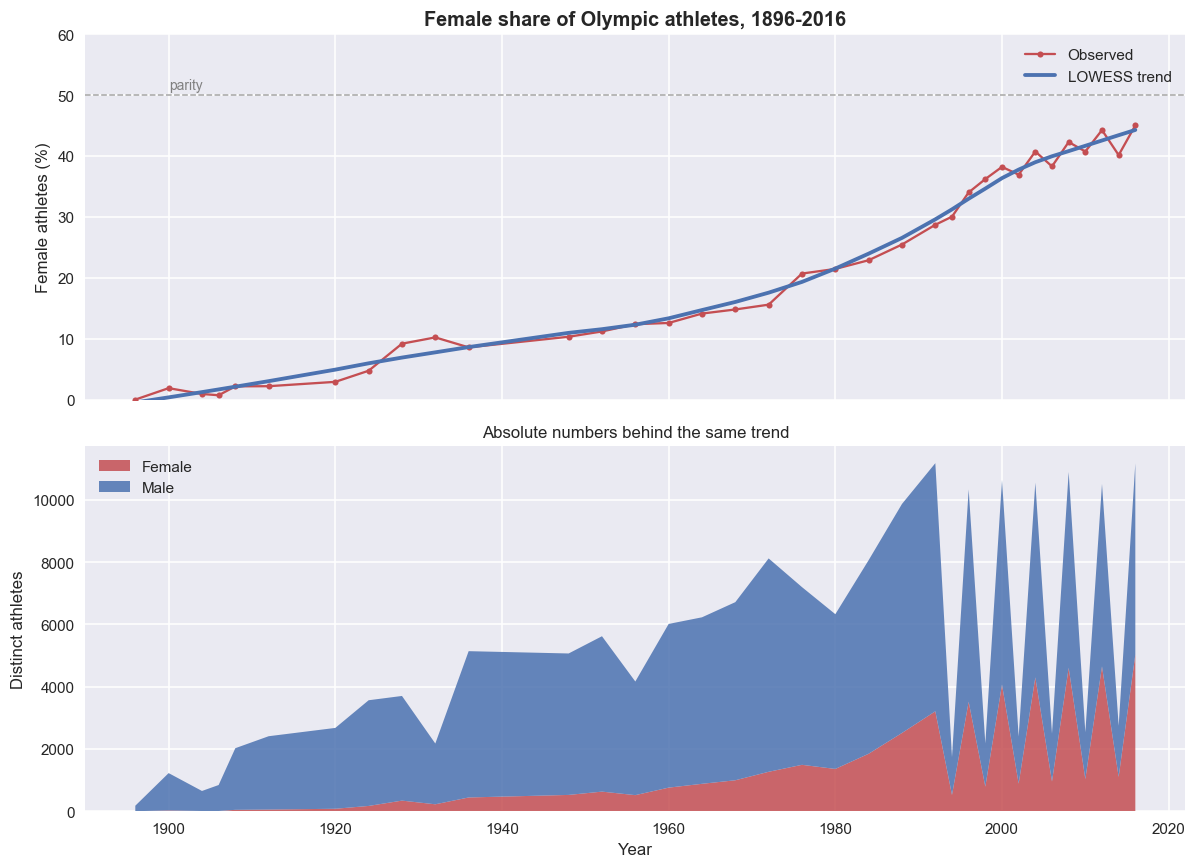

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

axes[0].plot(participation.index, participation["female_pct"],
             marker="o", markersize=4, linewidth=1.5, color="#c44e52", label="Observed")
smoothed = lowess(participation["female_pct"], participation.index, frac=0.35)
axes[0].plot(smoothed[:, 0], smoothed[:, 1], linewidth=2.5, color="#4c72b0",
             label="LOWESS trend")
axes[0].axhline(50, color="grey", linestyle="--", linewidth=1, alpha=0.7)
axes[0].text(1900, 51, "parity", color="grey", fontsize=9)
axes[0].set_ylabel("Female athletes (%)")
axes[0].set_ylim(0, 60)
axes[0].set_title("Female share of Olympic athletes, 1896-2016", fontsize=13, weight="bold")
axes[0].legend()

axes[1].stackplot(participation.index, participation["female"], participation["male"],
                  labels=["Female", "Male"], colors=["#c44e52", "#4c72b0"], alpha=0.85)
axes[1].set_ylabel("Distinct athletes")
axes[1].set_xlabel("Year")
axes[1].set_title("Absolute numbers behind the same trend", fontsize=11)
axes[1].legend(loc="upper left")

plt.tight_layout()
plt.show()

In [5]:
print(f"First Games ({participation.index[0]}): "
      f"{participation.iloc[0]['female_pct']:.1f}% female, "
      f"{participation.iloc[0]['female']:,.0f} of {participation.iloc[0]['total']:,.0f} athletes")
print(f"Last Games  ({participation.index[-1]}): "
      f"{participation.iloc[-1]['female_pct']:.1f}% female, "
      f"{participation.iloc[-1]['female']:,.0f} of {participation.iloc[-1]['total']:,.0f} athletes")
print(f"Largest single-Games increase: {participation['female_pct'].diff().idxmax()}, "
      f"+{participation['female_pct'].diff().max():.1f} percentage points")
print()
for era in [(1896, 1928), (1932, 1976), (1980, 2016)]:
    window = participation.loc[era[0]:era[1], "female_pct"]
    change = window.iloc[-1] - window.iloc[0]
    print(f"{era[0]}-{era[1]}: {window.iloc[0]:5.1f}% -> {window.iloc[-1]:5.1f}% "
          f"({change:+6.1f} points over {len(window)} Games, {change / len(window):+.2f} per Games)")

First Games (1896): 0.0% female, 0 of 176 athletes
Last Games  (2016): 45.0% female, 5,034 of 11,179 athletes
Largest single-Games increase: 1976, +5.1 percentage points

1896-1928:   0.0% ->   9.2% (  +9.2 points over 9 Games, +1.02 per Games)
1932-1976:  10.2% ->  20.7% ( +10.5 points over 10 Games, +1.05 per Games)
1980-2016:  21.5% ->  45.0% ( +23.6 points over 16 Games, +1.47 per Games)


### Observations

_Write your reading of the chart here. The printed figures above give you the numbers
to quote. Points worth addressing: when growth was flat and why, what changed around
1928 and again after 1976, whether the trend is approaching parity or flattening
below it, and what the second panel adds that the percentage alone hides._

## Sub-question 1.2: Which sports introduced female categories earliest, and which were the last?

Sports that have never recorded a female entrant are absent from these lists rather
than shown as null.

In [6]:
first_female = first_female_year_by_sport(games)

print(f"{len(first_female)} sports have recorded a female entrant.")
print(f"Range: {first_female.min()} to {first_female.max()}")
print()
print("Earliest ten:")
print(first_female.head(10).to_string())
print()
print("Latest ten:")
print(first_female.tail(10).to_string())

53 sports have recorded a female entrant.
Range: 1900 to 2016

Earliest ten:
Sport
Croquet           1900
Equestrianism     1900
Golf              1900
Sailing           1900
Tennis            1900
Archery           1904
Motorboating      1908
Figure Skating    1908
Diving            1912
Swimming          1912

Latest ten:
Sport
Water Polo      2000
Trampolining    2000
Taekwondo       2000
Triathlon       2000
Bobsleigh       2002
Skeleton        2002
Wrestling       2004
Boxing          2012
Ski Jumping     2014
Rugby Sevens    2016


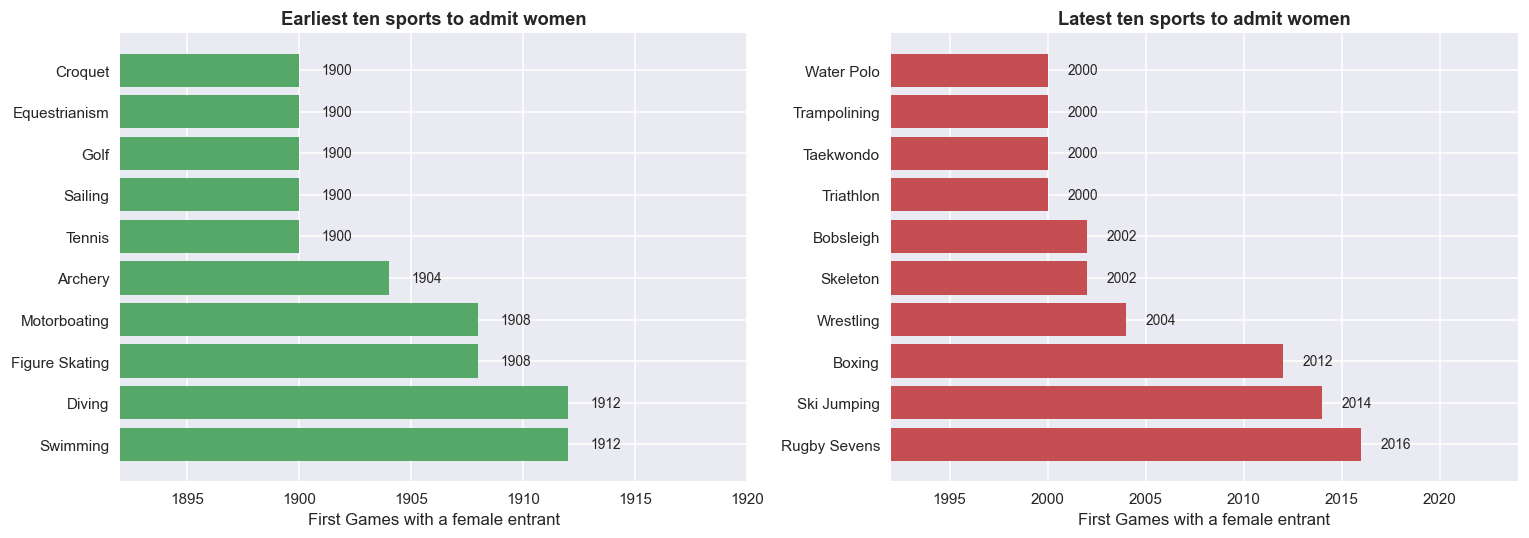

In [7]:
earliest = first_female.head(10)
latest = first_female.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, series, title, colour in [
    (axes[0], earliest, "Earliest ten sports to admit women", "#55a868"),
    (axes[1], latest, "Latest ten sports to admit women", "#c44e52"),
]:
    left = series.min() - 8
    ax.barh(series.index, series.values - left, left=left, color=colour)
    ax.set_xlim(left, series.max() + 8)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=12, weight="bold")
    ax.set_xlabel("First Games with a female entrant")
    for sport, year in series.items():
        ax.text(year + 1, sport, str(year), va="center", fontsize=9)

plt.tight_layout()
plt.show()

### Observations

_Your reading here. Consider what the earliest sports have in common and what that
suggests about which activities were considered acceptable for women at the time.
Then look at the latest group: how recent some of those dates are, and how far the
gap runs between the first sport and the last._

## Sub-question 1.3: Which countries have sent the highest number of female athletes in Olympic history?

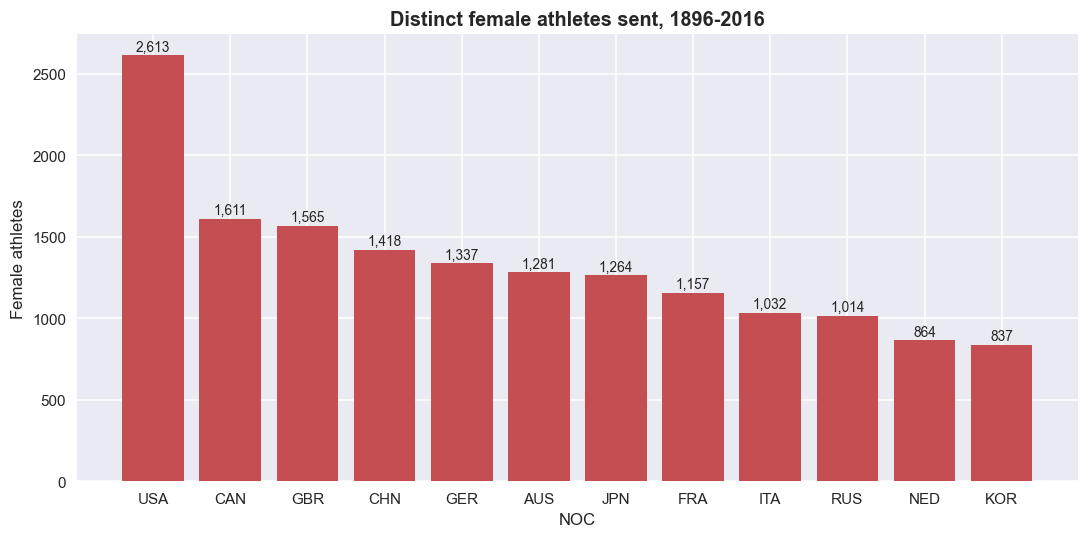

33,981 distinct female athletes in total.
These 12 nations account for 47.1% of them.


In [8]:
top_women = top_countries_by_female_athletes(games, top_n=12)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(top_women.index, top_women.values, color="#c44e52")
ax.set_title("Distinct female athletes sent, 1896-2016", fontsize=13, weight="bold")
ax.set_ylabel("Female athletes")
ax.set_xlabel("NOC")
for noc_code, value in top_women.items():
    ax.text(noc_code, value + 30, f"{value:,}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

total_women = games[games["Sex"] == "F"]["ID"].nunique()
print(f"{total_women:,} distinct female athletes in total.")
print(f"These {len(top_women)} nations account for {top_women.sum() / total_women:.1%} of them.")

### Observations

_Your reading here. The concentration figure printed above is the point worth
discussing: how much of global female participation sits in how few countries, and
what confounds a raw count of this kind._

# Research Question 2: How do countries perform in terms of overall success, specialization, and the impact of hosting?

## Sub-question 2.1: Which countries have the highest total medal counts?

Each team result counts once. Mixed-nationality entries are bucketed separately and
excluded from the country ranking, since they cannot be credited to any one nation.

In [9]:
table = medal_table(dedup)

# The table is ordered by gold first, the convention official medal tables use.
# The chart below ranks by total instead, to match its own title.
table.head(15)

Medal,Gold,Silver,Bronze,Total
NOC_final,,,,
USA,1128,898,788,2814
URS,470,373,353,1196
GER,318,345,339,1002
GBR,284,316,305,905
FRA,262,278,328,868
ITA,256,225,241,722
CHN,239,184,172,595
RUS,202,183,199,584
SWE,199,214,242,655


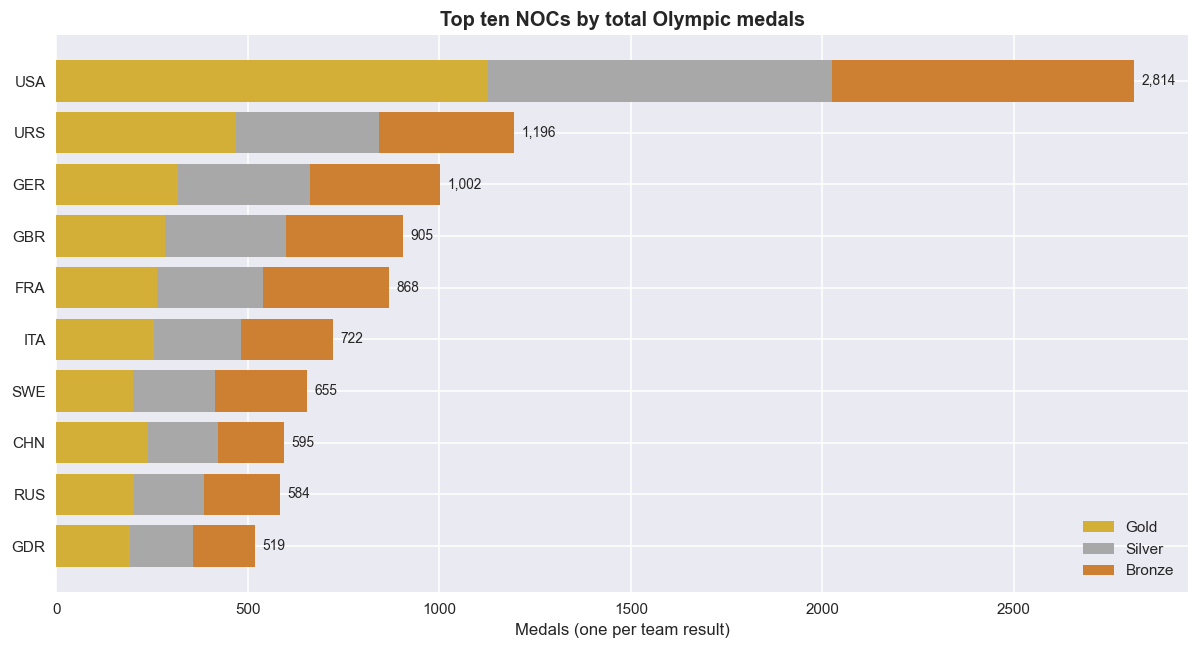

In [10]:
top10 = table.nlargest(10, "Total")

fig, ax = plt.subplots(figsize=(11, 6))
bottom = 0
for medal, colour in [("Gold", "#d4af37"), ("Silver", "#a8a8a8"), ("Bronze", "#cd7f32")]:
    ax.barh(top10.index, top10[medal], left=bottom, color=colour, label=medal)
    bottom = bottom + top10[medal]

ax.invert_yaxis()
ax.set_title("Top ten NOCs by total Olympic medals", fontsize=13, weight="bold")
ax.set_xlabel("Medals (one per team result)")
ax.legend(loc="lower right")
for noc_code, total in top10["Total"].items():
    ax.text(total + 20, noc_code, f"{total:,}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

### Observations

_Your reading here. Worth addressing: the size of the gap between first and second,
which entries in this list are states that no longer exist, and why that complicates
any ranking that spans 120 years._

## Sub-question 2.2: In which sports do the top medal-winning countries particularly excel?

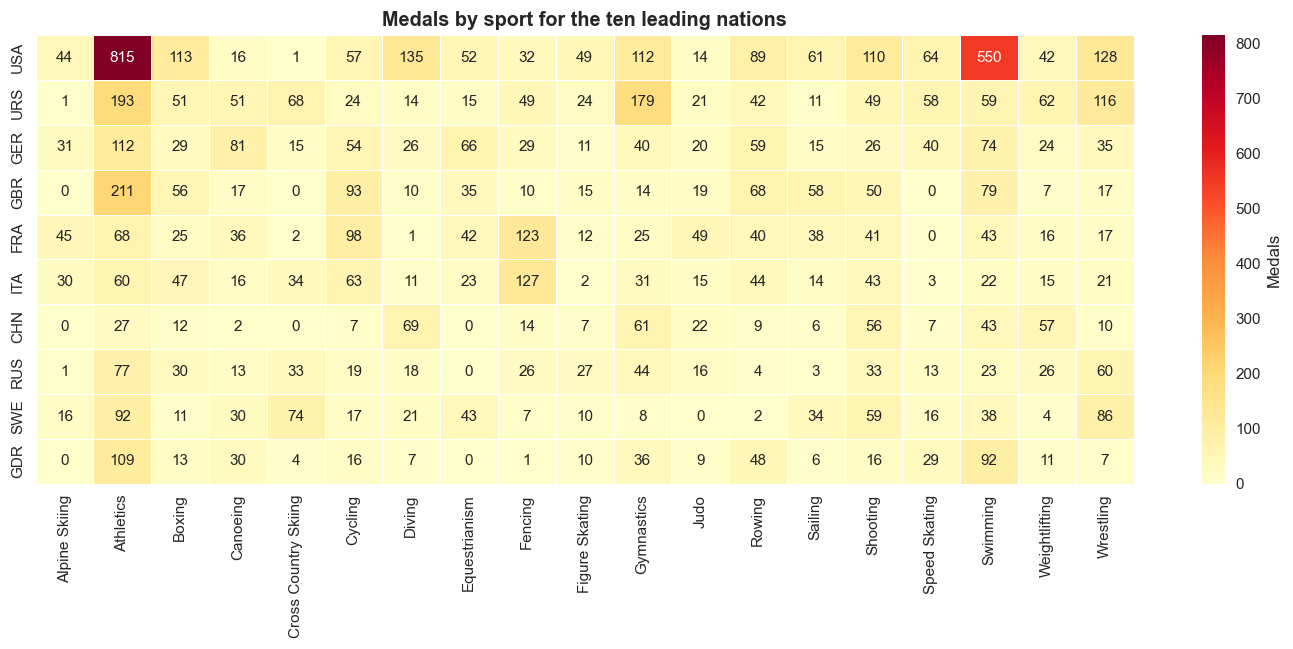

In [11]:
by_sport = medals_by_country_and_sport(dedup, top_n=10)
focus = by_sport.loc[:, by_sport.sum() >= 150]

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(focus, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5,
            cbar_kws={"label": "Medals"}, ax=ax)
ax.set_title("Medals by sport for the ten leading nations", fontsize=13, weight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [12]:
print("Single strongest sport for each of the leading nations:\n")
for noc_code in by_sport.index:
    row = by_sport.loc[noc_code]
    print(f"  {noc_code}: {row.idxmax()} ({row.max()} medals, "
          f"{row.max() / row.sum():.0%} of its total)")

Single strongest sport for each of the leading nations:

  USA: Athletics (815 medals, 29% of its total)
  URS: Athletics (193 medals, 16% of its total)
  GER: Athletics (112 medals, 11% of its total)
  GBR: Athletics (211 medals, 23% of its total)
  FRA: Fencing (123 medals, 14% of its total)
  ITA: Fencing (127 medals, 18% of its total)
  CHN: Diving (69 medals, 12% of its total)
  RUS: Athletics (77 medals, 13% of its total)
  SWE: Athletics (92 medals, 14% of its total)
  GDR: Athletics (109 medals, 21% of its total)


### Observations

_Your reading here. The concentration percentages printed above are the useful angle:
which nations spread their medals widely and which depend heavily on one or two
sports._

## Sub-question 2.3: Do host countries win more medals when hosting?

Two things are worth stating before the numbers.

**Hosts are read from the data, not from a list.** Every Games in the dataset carries
the city it was held in, so the host is derived rather than typed out. Only the
city-to-country mapping is external, and a test asserts that every city present in
the data has an entry. An earlier hardcoded year-to-country table listed Summer hosts
only, so Lillehammer 1994 was silently absent and Norway hosting its own Games never
entered the analysis at all.

**The baseline excludes the hosting year.** Comparing a hosting year against a mean
that contains it lets the observation contaminate its own control.

This is also the one sub-question reported separately by season. Winter medals are
concentrated in far fewer nations, so hosting cannot open the same breadth of new
events that it can in Summer. That makes the seasonal split a hypothesis worth
testing rather than a duplicated chart.

In [13]:
hosts = host_country_by_games(events)

print(f"{len(hosts)} Games resolved to a host country from the data")
print()
print(hosts[hosts["Season"] == "Winter"].tail(6).to_string(index=False))

51 Games resolved to a host country from the data

 Year Season           City host_country
 1994 Winter    Lillehammer       Norway
 1998 Winter         Nagano        Japan
 2002 Winter Salt Lake City          USA
 2006 Winter         Torino        Italy
 2010 Winter      Vancouver       Canada
 2014 Winter          Sochi       Russia


In [14]:
seasons = compare_seasons(dedup, noc, hosts)
seasons.round(4)

,n_pairs,n_repeat_host_countries,median_difference,mean_difference,median_ratio,statistic,p_value
Summer,29.0,5.0,20.8333,37.3723,2.4719,3.0,0.0000
Winter,22.0,8.0,1.1389,2.7272,1.0833,82.0,0.1484


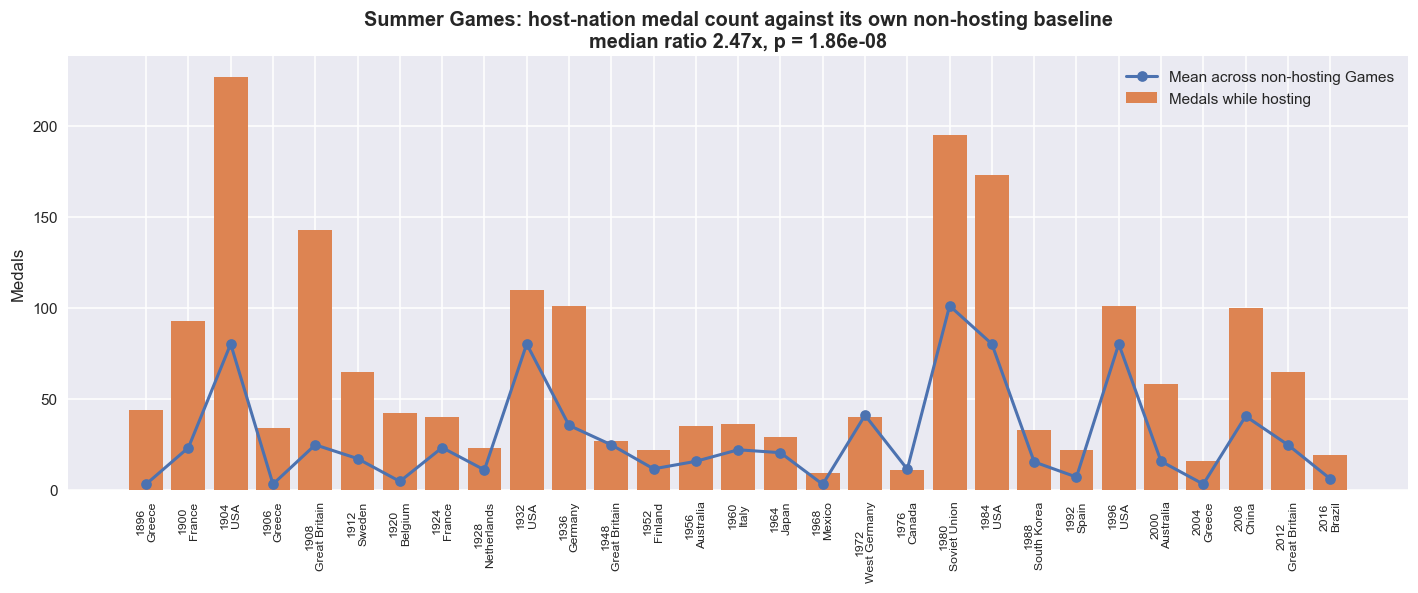

In [15]:
summer_hosts = host_vs_baseline(
    medals_by_year_and_country(dedup[dedup["Season"] == "Summer"], noc, hosts)
)
winter_hosts = host_vs_baseline(
    medals_by_year_and_country(dedup[dedup["Season"] == "Winter"], noc, hosts)
)

fig, ax = plt.subplots(figsize=(13, 5.5))
labels = [f"{y}\n{c}" for y, c in zip(summer_hosts["Year"], summer_hosts["country"])]
ax.bar(labels, summer_hosts["medals"], color="#dd8452", label="Medals while hosting")
ax.plot(labels, summer_hosts["baseline_medals"], color="#4c72b0", marker="o",
        linewidth=2, label="Mean across non-hosting Games")
ax.set_title("Summer Games: host-nation medal count against its own non-hosting baseline\n"
             f"median ratio {seasons.loc['Summer', 'median_ratio']:.2f}x, "
             f"p = {seasons.loc['Summer', 'p_value']:.3g}",
             fontsize=13, weight="bold")
ax.set_ylabel("Medals")
ax.tick_params(axis="x", rotation=90, labelsize=8)
ax.legend()
plt.tight_layout()
plt.show()

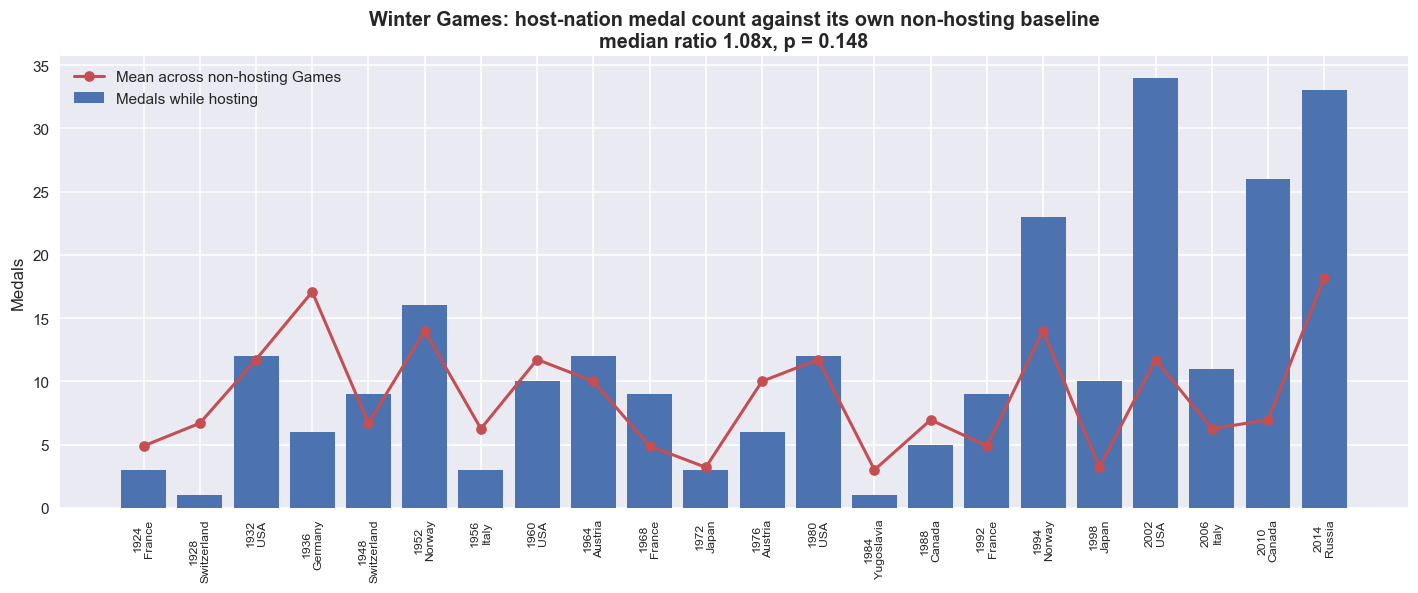

In [16]:
fig, ax = plt.subplots(figsize=(13, 5.5))
labels = [f"{y}\n{c}" for y, c in zip(winter_hosts["Year"], winter_hosts["country"])]
ax.bar(labels, winter_hosts["medals"], color="#4c72b0", label="Medals while hosting")
ax.plot(labels, winter_hosts["baseline_medals"], color="#c44e52", marker="o",
        linewidth=2, label="Mean across non-hosting Games")
ax.set_title("Winter Games: host-nation medal count against its own non-hosting baseline\n"
             f"median ratio {seasons.loc['Winter', 'median_ratio']:.2f}x, "
             f"p = {seasons.loc['Winter', 'p_value']:.3g}",
             fontsize=13, weight="bold")
ax.set_ylabel("Medals")
ax.tick_params(axis="x", rotation=90, labelsize=8)
ax.legend()
plt.tight_layout()
plt.show()

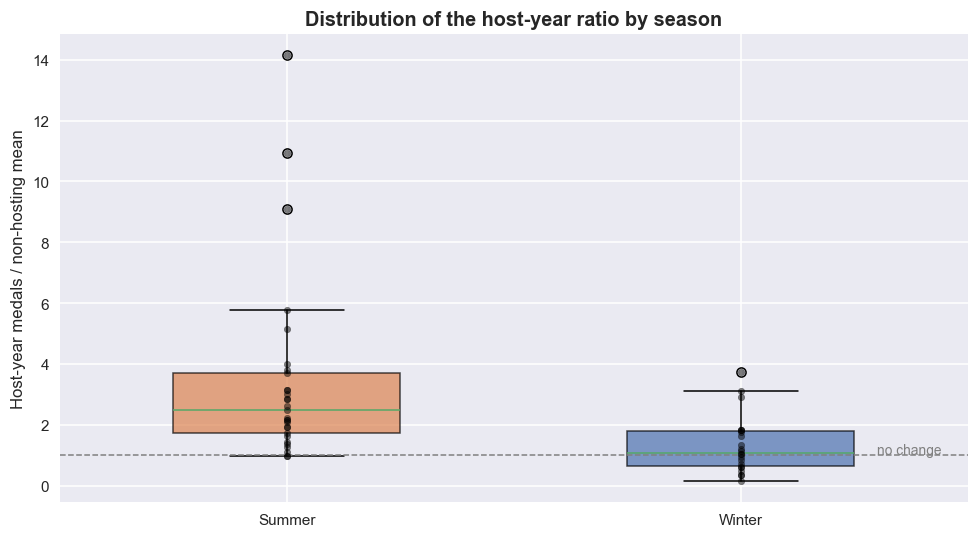

Summer: 2 of 29 hosts did worse than their own baseline
Winter: 9 of 22 hosts did worse than their own baseline


In [17]:
fig, ax = plt.subplots(figsize=(9, 5))

data = [summer_hosts["ratio"], winter_hosts["ratio"]]
parts = ax.boxplot(data, tick_labels=["Summer", "Winter"], patch_artist=True, widths=0.5)
for patch, colour in zip(parts["boxes"], ["#dd8452", "#4c72b0"]):
    patch.set_facecolor(colour)
    patch.set_alpha(0.7)

for i, series in enumerate(data, start=1):
    ax.scatter([i] * len(series), series, color="black", alpha=0.5, zorder=3, s=18)

ax.axhline(1.0, color="grey", linestyle="--", linewidth=1)
ax.text(2.3, 1.05, "no change", color="grey", fontsize=9)
ax.set_ylabel("Host-year medals / non-hosting mean")
ax.set_title("Distribution of the host-year ratio by season", fontsize=13, weight="bold")
plt.tight_layout()
plt.show()

for season, frame in [("Summer", summer_hosts), ("Winter", winter_hosts)]:
    print(f"{season}: {(frame['ratio'] < 1).sum()} of {len(frame)} hosts "
          f"did worse than their own baseline")

In [18]:
print("Winter hosting years, ordered by ratio:\n")
cols = ["Year", "country", "medals", "baseline_medals", "ratio"]
print(winter_hosts.sort_values("ratio", ascending=False)[cols]
      .to_string(index=False, float_format=lambda v: f"{v:.2f}"))

Winter hosting years, ordered by ratio:

 Year     country  medals  baseline_medals  ratio
 2010      Canada      26             6.95   3.74
 1998       Japan      10             3.20   3.12
 2002         USA      34            11.72   2.90
 1968      France       9             4.89   1.84
 1992      France       9             4.89   1.84
 2014      Russia      33            18.20   1.81
 2006       Italy      11             6.25   1.76
 1994      Norway      23            14.00   1.64
 1948 Switzerland       9             6.68   1.35
 1964     Austria      12            10.00   1.20
 1952      Norway      16            14.00   1.14
 1980         USA      12            11.72   1.02
 1932         USA      12            11.72   1.02
 1972       Japan       3             3.20   0.94
 1960         USA      10            11.72   0.85
 1988      Canada       5             6.95   0.72
 1924      France       3             4.89   0.61
 1976     Austria       6            10.00   0.60
 1956    

### Observations

**Summer: yes, and by a wide margin.** Across 29 hosting years with a usable
baseline, host nations won a median of 2.47 times their own non-hosting average, a
median difference of 20.8 medals (Wilcoxon signed-rank, p = 1.9e-08). The effect is
not driven by a handful of outliers: the interquartile range in the box plot sits
entirely above 1.0, and only 2 of 29 hosts finished below their own baseline.

**Winter: no measurable effect.** Across 22 hosting years the median ratio is 1.08
with p = 0.148. That does not permit the claim that hosting helps in Winter, and it
does not establish that it never helps either. With 22 pairs and this much variance,
the study simply cannot separate a small effect from none. 9 of the 22 Winter hosts
finished below their own baseline, including Switzerland in 1928, Germany in 1936 and
Yugoslavia in 1984.

**The seasonal gap has a structural explanation.** Summer medals are spread across
far more nations than Winter medals are. A Summer host can use its automatic
qualification places to enter events it would not otherwise reach, and some of those
entries convert. A Winter host cannot manufacture a bobsleigh or biathlon programme
from an entry quota, because the underlying capability is not there to be entered.
Hosting appears to widen participation rather than raise performance, which produces
medals only where breadth is available to be widened.

**The Winter series is not stationary.** Every host from 1994 onward finished above
its baseline: Norway 1994, Japan 1998, the United States 2002, Italy 2006, Canada
2010 and Russia 2014. The picture before 1994 is mixed and slightly negative. That is
six observations, so it is an observation and not a result, but it is consistent with
a change in how modern hosts prepare rather than with hosting itself conferring an
advantage. Testing it properly would need Games after 2014, which this dataset does
not contain.

**What this does not show.** Hosting is *associated* with higher medal counts in
Summer; nothing here establishes that hosting *causes* them. Hosts also field larger
delegations, enter more events, and invest across the four-year cycle beforehand. Any
of those could carry the entire effect, and this design cannot separate them.

**Caveat on the p-values.** Both are optimistic. Five countries hosted more than once
in Summer and eight in Winter, and each is compared against the same baseline every
time, so the pairs are not independent as the Wilcoxon signed-rank test assumes. The
Summer result is far enough from the threshold that its direction is not in doubt;
the Winter result was never near it.

# Conclusions

## Research Question 1: female participation

Female participation grew from 0% of athletes in 1896 to 45.0% in 2016, but the
growth was neither steady nor is it complete. Three eras are visible: near-stasis
through 1928, slow expansion to 1976, then acceleration from 1980 onward at roughly
1.5 percentage points per Games. The single largest jump, +5.1 points in 1976, aligns
with the IOC's expansion of women's events rather than with any shift in the athlete
population. The final four Games sit at 40.7%, 42.3%, 44.3% and 45.0%: still rising,
but by shrinking increments, and the trend line bends toward the horizontal below
parity rather than through it.

Across sports the picture is one of a 116-year staggered opening. The first entrants
appeared in 1900 in croquet, equestrianism, golf, sailing and tennis, all low-contact
pursuits already socially available to women. The last arrivals were combat and
high-risk sports: wrestling in 2004, boxing in 2012, ski jumping in 2014. Two of
those fall within the final fifteen years of the dataset, which places the closing of
this gap in the present rather than in history.

Across countries, participation is concentrated. Twelve nations account for 47.1% of
the 33,981 women who have competed. The ranking, however, measures attendance rather
than equality: Canada places second on female headcount without appearing in the top
ten by medals, because it fields large delegations at every Winter Games. A country
sending 2,000 women alongside 6,000 men outranks one that has reached parity at
smaller scale. Answering the equality question would require female share within each
delegation, which this analysis does not compute.

## Research Question 2: national performance

The United States leads with 2,814 medals, more than double the Soviet Union's 1,196,
with Germany third at 1,002. The gap between first and second exceeds the gap between
second and tenth. These figures depend entirely on a correction: counting raw rows
gives the United States 2,638 golds alone, against 1,128 once team results are
collapsed to one medal each. Any medal table built from this dataset without
deduplication overstates nations strong in team events, and does so by more than a
factor of two.

Specialisation is better read as a proportion than as a count. Athletics is the
strongest sport for seven of the ten leading nations, but the share it represents
ranges from 11% for Germany to 29% for the United States. That inverts the impression
the heatmap gives: the United States looks broad because its absolute numbers are
large everywhere, yet proportionally it is the most concentrated of the leaders.
Germany is the most diversified. Fencing marks a genuine national cluster in France
and Italy, and China shows the narrowest and most recent profile, peaking in diving.

Hosting is associated with a substantial advantage in Summer and none that can be
measured in Winter. Summer hosts won a median of 2.47 times their own non-hosting
average across 29 hosting years (p = 1.9e-08), with only 2 finishing below their
baseline. Winter hosts sit at 1.08 times with p = 0.148, and 9 of 22 finished below
their baseline. The most plausible reading is structural: a Summer host can convert
automatic qualification places into entries across a wide field of events, while a
Winter host cannot enter a discipline it has no athletes for. Hosting appears to
widen participation rather than raise performance, which yields medals only where
there is breadth to widen.

## What this analysis cannot show

**Association, not causation.** The hosting result compares medal counts, nothing
more. Hosts also field larger delegations, enter more events, and invest across the
preceding four-year cycle. Any of those could carry the entire effect, and a paired
comparison of totals cannot separate them.

**Dependent pairs.** Five countries hosted more than once in Summer and eight in
Winter, each measured against the same baseline every time. The Wilcoxon signed-rank
test assumes independent pairs, so both p-values are optimistic. The Summer result is
far enough from any threshold that its direction is not in question; the Winter
result was never close to one.

**Incomparable eras.** A medal from 1904, when 12 nations competed and the United
States won 228 of the medals awarded largely because few others travelled, counts the
same here as a medal from 2016. Totals accumulated across 120 years compare
fundamentally different competitions.

**Shifting states.** The Soviet Union, East and West Germany, Yugoslavia and the
Unified Team are treated as distinct entities rather than mapped to successor states.
Merging the German entries would place Germany second overall. This is a political
choice, not a statistical one, and the analysis declines to make it.

**Excluded entries.** Mixed-nationality teams are bucketed as ZZX and left out of
country rankings, since crediting them to any single nation would be arbitrary.

**Coverage.** The dataset ends at Rio 2016. Several of the observations above,
particularly the post-1994 pattern among Winter hosts, would need more recent Games
to test properly.